In [8]:
from netCDF4 import Dataset
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import matplotlib.cm as cm
import datetime 
import time
from scipy.fft import fft, ifft, fftshift
from scipy.fftpack import fftfreq

temp = np.zeros((8,64,128))
Q1   = np.zeros((8,64,128))
#for i,lev in enumerate([100]):
for i,lev in enumerate([100, 200, 250, 500,700,850,925,1000]):
    # Open the NetCDF file
    path           = "/home/kaichiht/Colab/2025_research/Dycore_obs_Climatology/IdealizeSpetral.jl/exp/HSt42/obs_theta/"
    nc_file        = Dataset(path+"t"+str(lev)+'_clim.nc', mode="r")
    temp[i,:,:]    = nc_file.variables["t"][:].mean(axis=0)
    nc_file        = Dataset(path+"Q1"+str(lev)+'_clim.nc', mode="r")
    Q1[i,:,:]      = nc_file.variables["q1"][:].mean(axis=0)
    lon            = nc_file.variables["lon"][:]
    lat            = nc_file.variables["lat"][:]
    nc_file.close()
# # Print file metadata
# print(nc_file)

# # Get variable names
# print(nc_file.variables.keys())

# # Access a specific variable
# temp = nc_file.variables["temperature"][:]  # Change "temperature" to a variable in your file
# print(temp)

# # Close file
# nc_file.close()


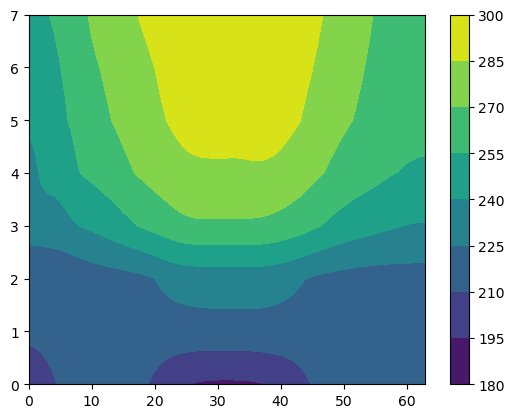

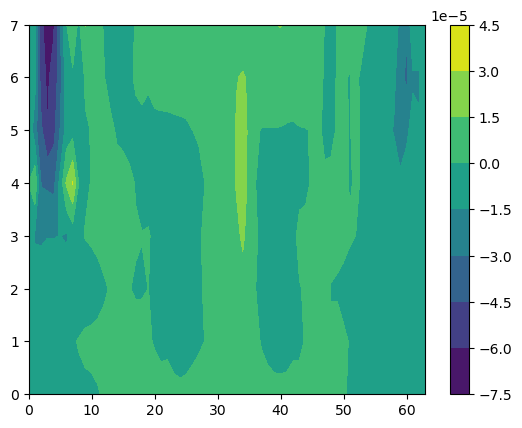

In [2]:
plt.figure()
cs = plt.contourf(temp[:,:,:].mean(axis=(2)))
plt.colorbar(cs)

plt.figure()
cs = plt.contourf(Q1[:,:,:].mean(axis=(2)))
plt.colorbar(cs)

## Load Dycore file for interpolating the ERA5 data into dycore grid 


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import matplotlib.cm as cm
import datetime 
import time
from Load_File import Load_File

#del tmp
# start_day = 0
# end_day   = 500

def load_file(PR, start_day, end_day, path, load_variable='none'):
    tmp = []
    for i in range(start_day, end_day+25, 25):
        #path          = '/work/kaichiht/Colab/2025_research/Dycore_obs_Climatology/IdealizeSpetral.jl/exp/HSt42/HSt42_0/'
        
        file_path     = path+'RH80_PR'+str(PR)+'_'+str(end_day)+'day_startfrom_'+str(i)+'day_final.dat'
        f             = Load_File(load_variable)
        if i == start_day:
            with h5py.File(file_path, "r") as file:
                print(file.keys())
        print(i)
        if os.path.exists(file_path):
            if i==0:
                tmp = np.array(f.load_data(file_path))
            else:
                tmp = np.concatenate((tmp,np.array(f.load_data(file_path))))
    
    return tmp
path              = '/work/kaichiht/Colab/2025_research/Dycore_obs_Climatology/IdealizeSpetral.jl/exp/HSt42/HSt42_0/'
grid_t_c_xyzt     = load_file(0, 0, 500, path, 'grid_t_c_xyzt')
grid_p_full_xyzt  = load_file(0, 0, 500, path, 'grid_p_full_xyzt')

<KeysViewHDF5 ['_types', 'convection_xyzt', 'factor1_xyzt', 'factor2_xyzt', 'factor3_xyzt', 'factor4_xyzt', 'grid_div_xyzt', 'grid_geopots_xyzt', 'grid_p_full_xyzt', 'grid_p_half_xyzt', 'grid_ps_c_xyzt', 'grid_ps_p_xyzt', 'grid_t_c_xyzt', 'grid_t_n_xyzt', 'grid_t_p_xyzt', 'grid_tracers_c_max_Tiffany_xyzt', 'grid_tracers_c_max_xyzt', 'grid_tracers_c_xyzt', 'grid_tracers_diff_xyzt', 'grid_tracers_n_xyzt', 'grid_tracers_p_xyzt', 'grid_u_c_xyzt', 'grid_u_n_xyzt', 'grid_u_p_xyzt', 'grid_v_c_xyzt', 'grid_v_n_xyzt', 'grid_v_p_xyzt', 'grid_vor_xyzt', 'grid_w_full_xyzt', 'grid_z_full_xyzt', 'grid_δtracers_xyzt', 'grid_δu_xyzt', 'grid_δv_xyzt', 'spe_div_c_xyzt', 'spe_div_p_xyzt', 'spe_lnps_c_xyzt', 'spe_lnps_p_xyzt', 'spe_t_c_xyzt', 'spe_t_p_xyzt', 'spe_tracers_c_xyzt', 'spe_tracers_p_xyzt', 'spe_vor_c_xyzt', 'spe_vor_p_xyzt']>
0
25
50
75
100
125
150
175
200
225
250
275
300
325
350
375
400
425
450
475
500
<KeysViewHDF5 ['_types', 'convection_xyzt', 'factor1_xyzt', 'factor2_xyzt', 'factor3_xyzt',

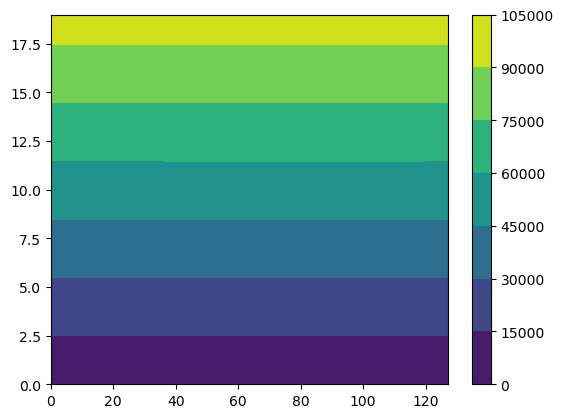

In [10]:
plt.figure()
cs = plt.contourf(grid_p_full_xyzt[:,:,:,:].mean(axis=(0,2)))
plt.colorbar(cs)

In [5]:
Dycore_p = grid_p_full_xyzt[:,:,:,:].mean(axis=(0,2,3))/np.max(grid_p_full_xyzt[:,:,:,:].mean(axis=(0,2,3)))
ERA5_p   = np.array([0.100, 0.200, 0.250, 0.500,0.700,0.850,0.925,1.000])

from scipy.interpolate import interp1d
import numpy as np

temp_Dycore = np.zeros((20,64,128))
Q1_Dycore   = np.zeros((20,64,128))
# Create an interpolation function with extrapolation
for i in range(64):
    for j in range(128):
        f                  = interp1d(ERA5_p, temp[:,i,j], kind="linear", fill_value="extrapolate")
        temp_Dycore[:,i,j] = f(Dycore_p)
        f                  = interp1d(ERA5_p, Q1[:,i,j], kind="linear", fill_value="extrapolate")
        Q1_Dycore[:,i,j]   = f(Dycore_p)


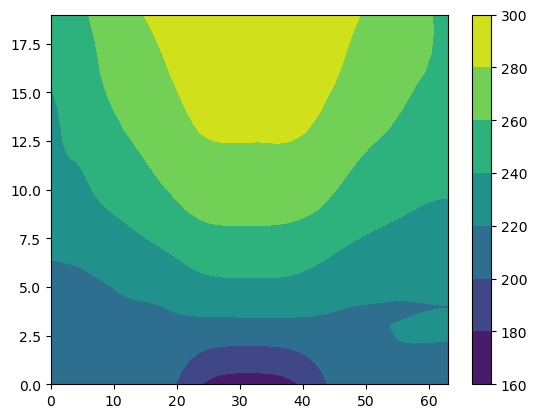

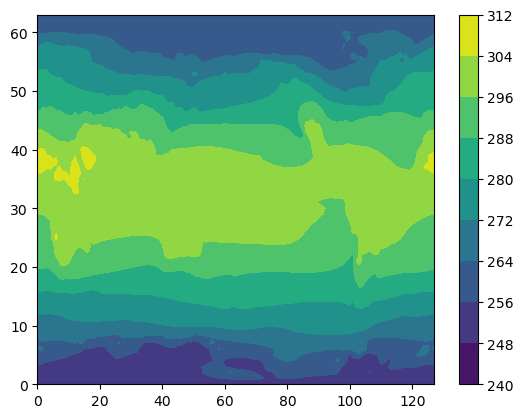

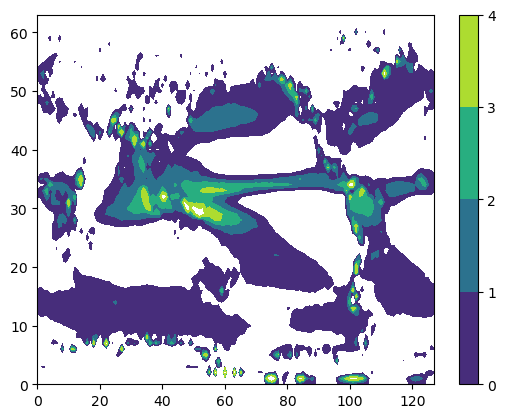

In [6]:
plt.figure()
cs = plt.contourf(temp_Dycore[:,:,:].mean(axis=(2)))
plt.colorbar(cs)
plt.figure()
cs = plt.contourf(temp_Dycore[19,:,:])
plt.colorbar(cs)

plt.figure()
cs = plt.contourf(Q1_Dycore[10,:,:]*86400,levels = np.arange(0,5,1))
plt.colorbar(cs)


In [56]:
#del k_t_3D
k_t_3D = np.tile(k_t[..., np.newaxis],(1,1,128))


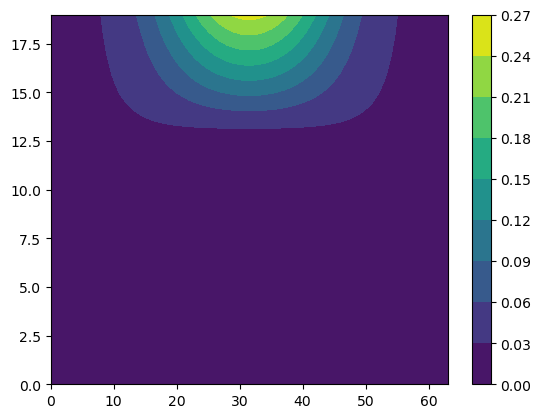

In [58]:
plt.figure()
cs=plt.contourf(k_t_3D.mean(axis=2))
plt.colorbar(cs)

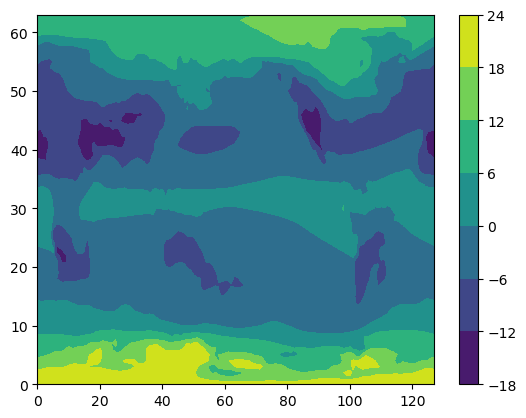

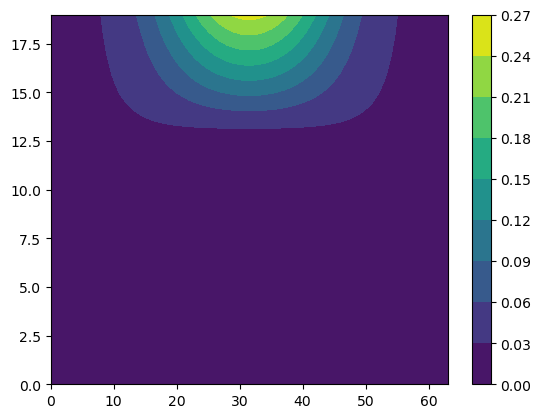

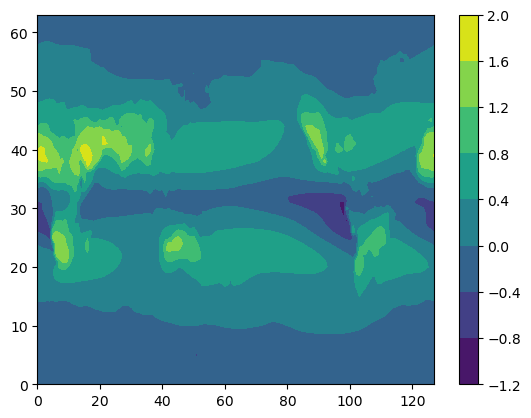

In [65]:
# calculate the new forcing term

p     = grid_p_full_xyzt[:,:,:,:].mean(axis=(0,3))
sigma = grid_p_full_xyzt[:,:,:,:].mean(axis=(0))/grid_p_full_xyzt[:,19,:,:].mean(axis=(0))
plt.figure()
cs=plt.contourf(grid_t_c_xyzt[1600:,:,:,:].mean(axis=0)[19,:,:]-temp_Dycore[19,:,:])
plt.colorbar(cs)

#Q_N = Q1_Dycore - (grid_t_c_xyzt[1600:,:,:,:].mean(axis=0)-temp_Dycore)
# create kt profile 

k_a = 1/40
k_s = 1/4
k_t = k_a + (k_s-k_a)*np.maximum(0,(p/p[19,:]-0.7)/(1-0.7))*np.cos(lat/180*np.pi)**4
k_t_3D = np.tile(k_t[..., np.newaxis],(1,1,128))


plt.figure()
cs=plt.contourf(k_t)
plt.colorbar(cs)


Q_N = (Q1_Dycore - 2/3*(grid_t_c_xyzt[1600:,:,:,:].mean(axis=0)-temp_Dycore)*k_t_3D)
plt.figure()
cs=plt.contourf(Q_N[19,:,:])
plt.colorbar(cs)

In [33]:
import h5py
import numpy as np

## Write Regrid File into and HDF5 file 
file_path = '/home/kaichiht/Colab/2025_research/Dycore_obs_Climatology/IdealizeSpetral.jl/exp/HSt42/obs_theta/'
file_name = 'grid_t_obs.dat'


# Create a new HDF5 file
with h5py.File(file_path+file_name, "w") as hdf:
    # Define data for variable T
    T = np.random.rand(10, 10)  # Example: 10x10 array with random values

    # Create a dataset in the HDF5 file
    hdf.create_dataset("T", data=temp_Dycore)

    # Optionally, add attributes (metadata)
    hdf["T"].attrs["units"] = "Kelvin"
    hdf["T"].attrs["description"] = "Temperature data"

## Write Regrid File into and HDF5 file 
file_path = '/home/kaichiht/Colab/2025_research/Dycore_obs_Climatology/IdealizeSpetral.jl/exp/HSt42/obs_theta/'
file_name = 'grid_Q1'+str(iteration)+'.dat'


# Create a new HDF5 file
with h5py.File(file_path+file_name, "w") as hdf:
    # Define data for variable T
    T = np.random.rand(10, 10)  # Example: 10x10 array with random values

    # Create a dataset in the HDF5 file
    hdf.create_dataset("Q1", data=Q1_Dycore)

    # Optionally, add attributes (metadata)
    hdf["Q1"].attrs["units"] = "Kelvin/s"
    hdf["Q1"].attrs["description"] = "Heating data"
    